### ** Difference Between Simple And Multiple Linear Regression

- Simple linear regression has only one x and one y variable.
- Multiple linear regression has one y and two or more x variables.
- For instance, when we predict rent based on square feet alone that is simple linear regression.
- When we predict rent based on square feet and age of the building that is an example of multiple linear regression.

In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
cd /content/drive/MyDrive/ML/Regression

/content/drive/MyDrive/ML/Regression


### An extension of simple linear regression
In simple linear regression there is a one-to-one relationship between the input variable and the output variable.
But in multiple linear regression, as the name implies there is a many-to-one relationship, instead of just using one input variable, you use several.

### Multiple Linear Regression

Till now, we have created the model based on only one feature. Now, we’ll include multiple features and create a model to see the relationship between those features and the label column.
This is called **Multiple Linear Regression**.

y = b0 + b1x1+ b2x2... + bnxn

 What do terms represent?
- y is the response or the target variable
- x1,x2,x3...xn  are the feature as it is multiple
- b1,b2...bn are the coefficient of x1,x2,..xn respectively
- b0 is the intercept

Each $x$ represents a different feature, and each feature has its own coefficient

## Implementation

### Step1: Import data

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [98]:
dataset = pd.read_csv('/content/drive/MyDrive/ML/Regression/dataset/50_Startups.csv')

In [99]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [100]:
#categorical data
import plotly.express as px
px.pie(dataset , names='State')

- See here more than one feature so it is multiplt linear regression
- Here Profit is our Target Feature

array([[<Axes: title={'center': 'R&D Spend'}>,
        <Axes: title={'center': 'Administration'}>],
       [<Axes: title={'center': 'Marketing Spend'}>,
        <Axes: title={'center': 'Profit'}>]], dtype=object)

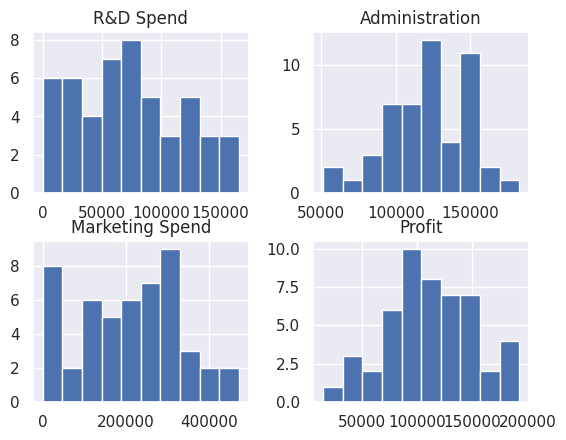

In [101]:
dataset.hist()

<Axes: xlabel='State', ylabel='Profit'>

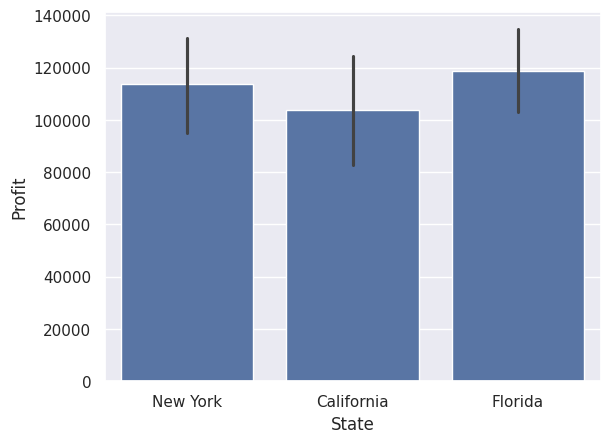

In [102]:
sns.set()
sns.barplot(data =dataset , x = 'State' , y = 'Profit')

<Axes: >

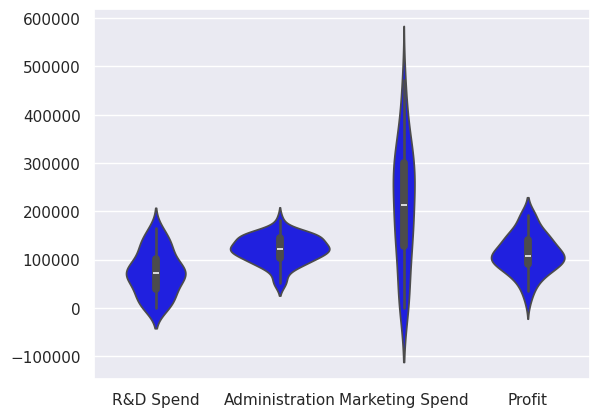

In [121]:
sns.violinplot(data=dataset,color='blue')

In [104]:
dataset.shape

(50, 5)

### Step2: Visuallize The Data

In [ ]:
#sns.pairplot(dataset)

In [105]:
dataset = dataset.drop('State',axis=True)

- Here i simply drop the State feature.
- in next some days i will show how to deal with categorical feature.

In [106]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,Profit
0,165349.20,136897.80,471784.10,192261.83
1,162597.70,151377.59,443898.53,191792.06
2,153441.51,101145.55,407934.54,191050.39
3,144372.41,118671.85,383199.62,182901.99
4,142107.34,91391.77,366168.42,166187.94


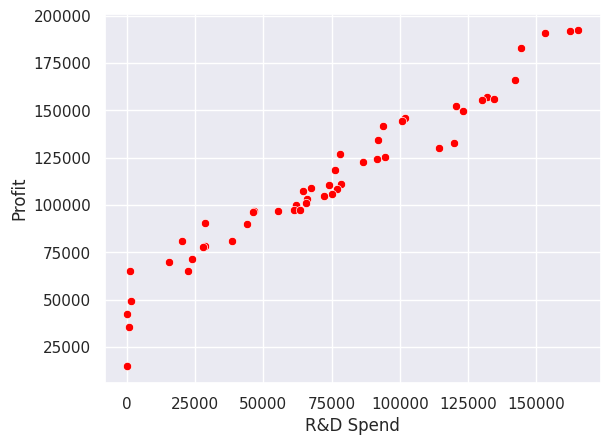

In [107]:
sns.scatterplot(x='R&D Spend',y='Profit',data=dataset, color="red");

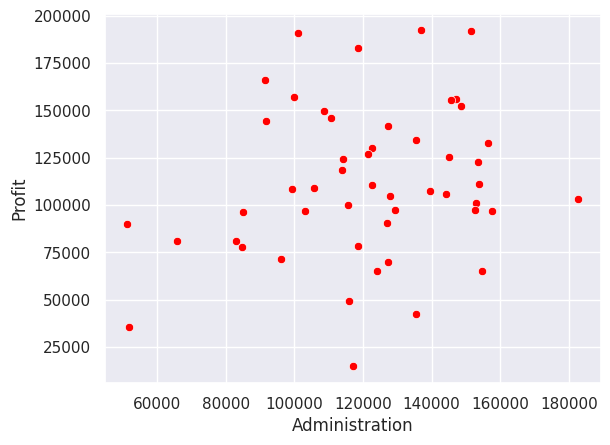

In [108]:
sns.scatterplot(x='Administration',y='Profit',data=dataset, color="red");

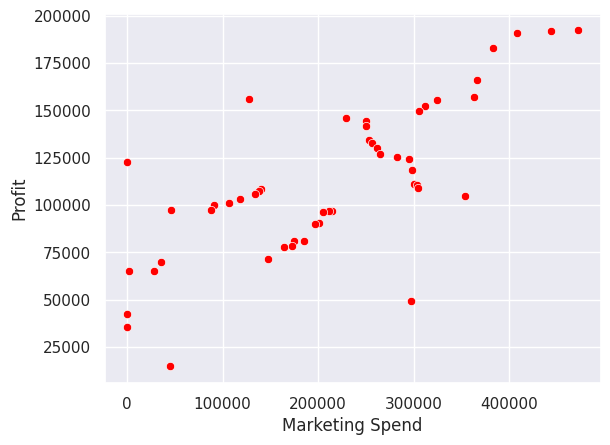

In [109]:
sns.scatterplot(x='Marketing Spend',y='Profit',data=dataset, color="red");

<Axes: >

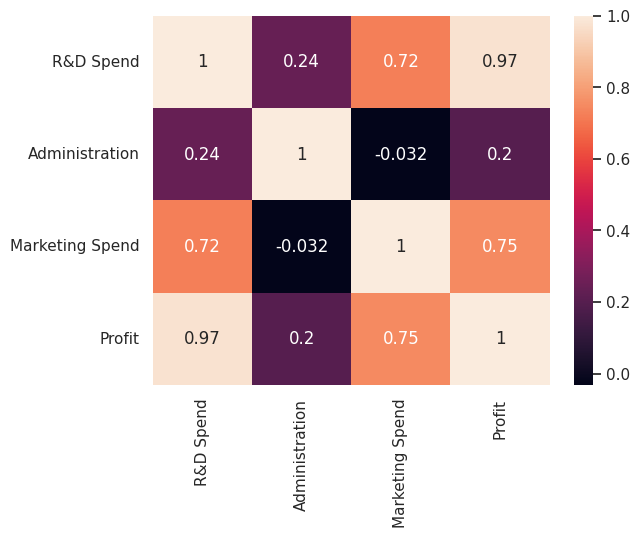

In [110]:
corr = dataset.corr()
sns.heatmap(corr,annot=True)

## Evaluate The Model

## Scalling The Data

In [111]:
X = dataset.drop('Profit',axis=True)
y = dataset['Profit']

In [112]:
X.head() #before standardized data

,R&D Spend,Administration,Marketing Spend
0,165349.20,136897.80,471784.10
1,162597.70,151377.59,443898.53
2,153441.51,101145.55,407934.54
3,144372.41,118671.85,383199.62
4,142107.34,91391.77,366168.42


In [113]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

 - As here all data are in very big range so we need to take all the data in same range.
 - So here i use StandardScaler which take all data in same range
 - here it use z score to standardized data
 - Z- score formula

                                      Z = x-μ /σ



- Z	=	standard score
- x	=	observed value
- μ	=	mean of the sample
-  σ =	standard deviation of the sample

- Some Of the Algorithm Like Tree Base Algorithm not require scalling

In [114]:
X #after standardized/scalling data

array([[ 2.01641149e+00,  5.60752915e-01,  2.15394309e+00],
       [ 1.95586034e+00,  1.08280658e+00,  1.92360040e+00],
       [ 1.75436374e+00, -7.28257028e-01,  1.62652767e+00],
       [ 1.55478369e+00, -9.63646307e-02,  1.42221024e+00],
       [ 1.50493720e+00, -1.07991935e+00,  1.28152771e+00],
       [ 1.27980001e+00, -7.76239071e-01,  1.25421046e+00],
       [ 1.34006641e+00,  9.32147208e-01, -6.88149930e-01],
       [ 1.24505666e+00,  8.71980011e-01,  9.32185978e-01],
       [ 1.03036886e+00,  9.86952101e-01,  8.30886909e-01],
       [ 1.09181921e+00, -4.56640246e-01,  7.76107440e-01],
       [ 6.20398248e-01, -3.87599089e-01,  1.49807267e-01],
       [ 5.93085418e-01, -1.06553960e+00,  3.19833623e-01],
       [ 4.43259872e-01,  2.15449064e-01,  3.20617441e-01],
       [ 4.02077603e-01,  5.10178953e-01,  3.43956788e-01],
       [ 1.01718075e+00,  1.26919939e+00,  3.75742273e-01],
       [ 8.97913123e-01,  4.58678535e-02,  4.19218702e-01],
       [ 9.44411957e-02,  9.11841968e-03

In [115]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: >]], dtype=object)

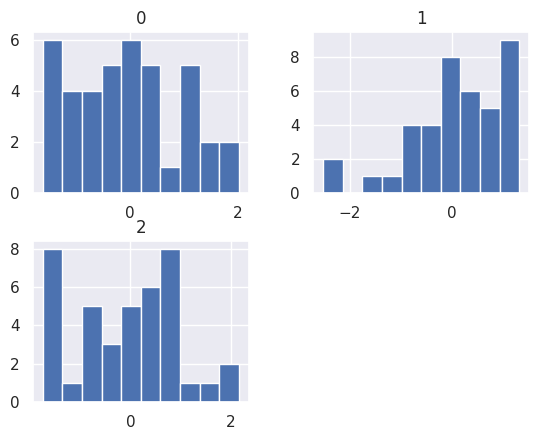

In [117]:
#X_train = pd.DataFrame(X_train)
X_train.hist()

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: >]], dtype=object)

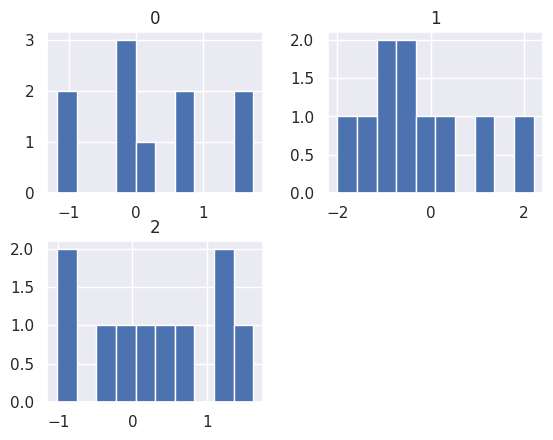

In [118]:
x_test = pd.DataFrame(X_test)
x_test.hist()

In [119]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((40, 3), (10, 3), (40,), (10,))

## Build  Model

In [56]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [57]:
y_pred = regressor.predict(X_test).round(1)

In [58]:
calculation = pd.DataFrame(np.c_[y_test,y_pred], columns = ["Original Salary","Predict Salary"])
calculation.head(5)

,Original Salary,Predict Salary
0,103282.38,103901.9
1,144259.40,132763.1
2,146121.95,133567.9
3,77798.83,72911.8
4,191050.39,179627.9


In [59]:
print("Training Accuracy :", regressor.score(X_train, y_train))
print("Testing Accuracy :", regressor.score(X_test, y_test))

Training Accuracy : 0.9499572530324031
Testing Accuracy : 0.939395591782057


In [60]:
regressor.intercept_

111297.71256204927

In [61]:
regressor.coef_

array([35391.2501208 ,   815.21987542,  4202.06618916])

### Test The Model

In [62]:
feature = [165349.20,136897.80,471784.10]
scale_feature = sc.transform([feature])
scale_feature

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[2.01641149, 0.56075291, 2.15394309]])

In [63]:
y_pred_test = regressor.predict(scale_feature)
y_pred_test  #By Using Sklearn Library

array([192169.18440985])

In [64]:
# Here I use b1x1+b2x2+b3x3+b0 BY MANUAL
35391.2501208*2.01641149+815.21987542*0.56075291+4202.06618916*2.15394309+ 111297.71256204927

192169.1843003897

- Now above you see manual and automatic prediction on the same data in this way linear regression predict the data

In [67]:
import pickle

In [68]:
# Save Model To a File Using Python Pickle
with open('multiple_Regression_Model','wb') as file:
    pickle.dump(regressor,file)

In [69]:
# Load Saved Model
with open('multiple_Regression_Model','rb') as file:
    my_pickle_model = pickle.load(file)

In [71]:
import joblib

In [72]:
# Save Trained Model Using joblib

joblib.dump(regressor, 'joblib_model_MultipleRegression')

['joblib_model_MultipleRegression']

In [73]:
# Save Trained Model Using joblib

joblib.dump(regressor, 'joblib_model_MultipleRegression')

['joblib_model_MultipleRegression']

In [74]:
# Loading the Model
my_joblib_model = joblib.load('joblib_model_MultipleRegression')

In [75]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming you have predictions and true values
y_pred = regressor.predict(X_test)

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# R-squared (R²) Score
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 77506468.17
Mean Absolute Error (MAE): 7320.44
R-squared (R²): 0.94


In [76]:
# Compute R²
r2 = r2_score(y_test, y_pred)

# Number of samples (n) and predictors (k)
n = X_test.shape[0]  # Number of samples
k = X_test.shape[1]  # Number of features

# Compute Adjusted R²
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print(f"R-squared (R²): {r2:.2f}")
print(f"Adjusted R-squared: {adjusted_r2:.2f}")

R-squared (R²): 0.94
Adjusted R-squared: 0.91


In [123]:
# Create a new DataFrame, `df` that takes two columns from `data`: `Marketing Spend` and `Profit`
df = pd.DataFrame({'Marketing Spend': dataset['Marketing Spend'],'Profit': dataset['Profit']})
df.head(3)

,Marketing Spend,Profit
0,471784.10,192261.83
1,443898.53,191792.06
2,407934.54,191050.39


In [124]:
# Reshape the data
X = df['Marketing Spend'].values.reshape(-1, 1)
y = df['Profit'].values

# Create a linear regression model
model = LinearRegression()

# Fit the model to our data
model.fit(X, y)

# Predict the sales values
predictions = model.predict(X)

# Extract the slope (m) and intercept (c)
m = model.coef_[0]
c = model.intercept_

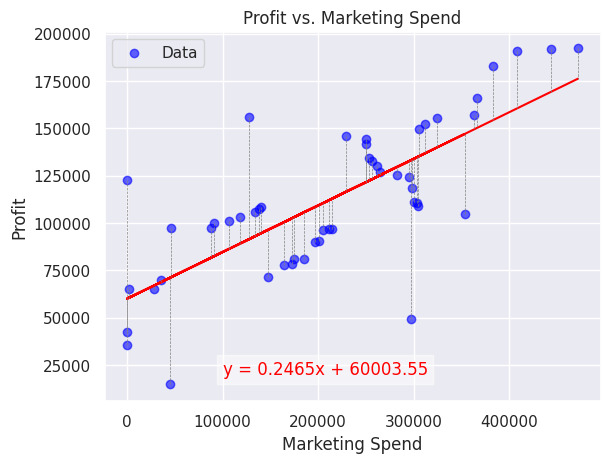

In [125]:
# Generate a scatter plot of `Profit` by `Marketing Spend`
plt.scatter(X, y, c='blue',  alpha=0.6, label='Data')
plt.title('Profit vs. Marketing Spend')
plt.xlabel('Marketing Spend')
plt.ylabel('Profit')
plt.legend()

# Display the regression line and its equation on the plot
plt.plot(X, predictions, color='red', label='Regression Line')
equation = f"y = {m:.4f}x + {c:.2f}"
plt.text(100000, 20000, equation, fontsize=12, color='red', bbox=dict(facecolor='white', alpha=0.5));

# Display the residuals on the plot
for i in range(len(X)):
    plt.plot([X[i], X[i]], [y[i], predictions[i]], color='gray', linestyle='--', linewidth=0.5)
plt.plot([], [], color='gray', linestyle='--', linewidth=0.5, label='Residuals')